Device: cuda
Monument vector geometry breakdown:
Polygon    1182
Name: count, dtype: int64

Scanning dataset folders...
  train        →  site: 876   no_site: 2720  total: 3596
  validation   →  site: 326   no_site: 919   total: 1245
  test         →  site: 226   no_site: 652   total: 878
Preloading and caching 3596 Train patches into RAM...
Preloading and caching 1245 Eval patches into RAM...
Preloading and caching 878 Eval patches into RAM...

  Training Pipeline | Trained From Scratch (No Pretraining) | Epochs: 30
Ep 01/30 | LR: 9.97e-05  ✓ saved | No Improve: 0/7
  Train -> Loss: 0.3189 (Cls: 0.1374, Msk: 0.9073) | AUC: 0.5173 | F1: 0.6094 | Prec: 0.5096 | Rec: 0.7579
  Val   -> Loss: 0.2934 (Cls: 0.1398, Msk: 0.7682) | AUC: 0.5918 | F1: 0.4169 | Prec: 0.2633 | Rec: 1.0000
Ep 02/30 | LR: 9.89e-05  ✓ saved | No Improve: 0/7
  Train -> Loss: 0.2995 (Cls: 0.1354, Msk: 0.8204) | AUC: 0.5336 | F1: 0.6319 | Prec: 0.5200 | Rec: 0.8049
  Val   -> Loss: 0.2752 (Cls: 0.1385, Msk: 0.6836) | A

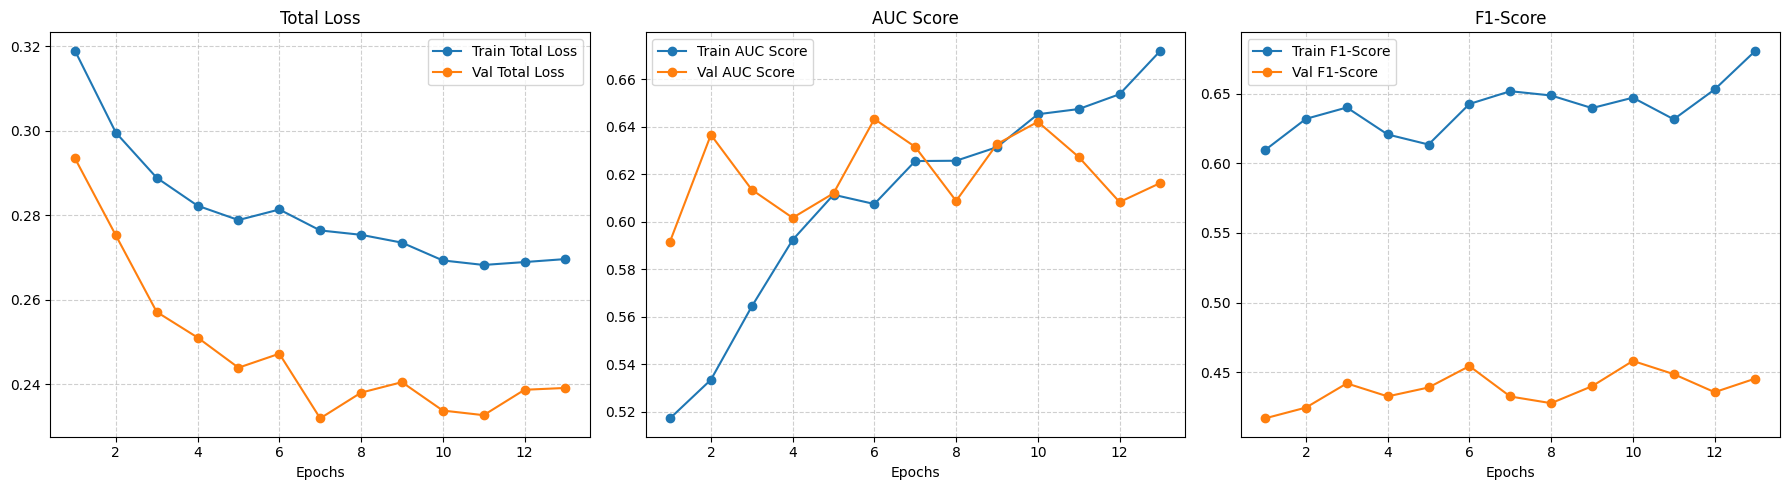


Loading best checkpoint from efficientnet_b0_lidar_aux_best.pth...

      FINAL BENCHMARK: UNTOUCHED TEST SET
Optimal Cutoff Calibrated from Val : 0.5200 (Val F1: 0.4651, Val AUC: 0.6433)

Test Performance @ Default Cutoff (0.50):
  • AUC       : 0.6526
  • F1 Score  : 0.4604
  • Precision : 0.3158
  • Recall    : 0.8496
  • Accuracy  : 0.4875

Test Performance @ Calibrated Cutoff (0.5200):
  • AUC       : 0.6526
  • F1 Score  : 0.4598
  • Precision : 0.3404
  • Recall    : 0.7080
  • Accuracy  : 0.5718


In [8]:
# !pip install -q rasterio geopandas shapely pyproj
import os, random, warnings, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torchvision.models as models
import torchvision.transforms.functional as TF
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    precision_recall_curve
)

import rasterio
from rasterio.features import rasterize
import geopandas as gpd
import pyproj
from shapely.geometry import box

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

torch.backends.cudnn.benchmark = True

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
class CFG:
    ROOT                 = Path('/kaggle/input/datasets/shreyansdeshpande/200x200/FINALCNNDATA_200')
    MONUMENT_VECTOR_PATH = Path('/kaggle/input/datasets/shreyansdeshpande/monuments/monuments_inside_valid_dtm.gpkg')
    OUTPUT_DIR           = Path('/kaggle/working')

    TRAIN_SITE    = ROOT / 'train' / 'site'
    TRAIN_NOSITE  = ROOT / 'train' / 'no_site'
    VAL_SITE      = ROOT / 'validation' / 'site'
    VAL_NOSITE    = ROOT / 'validation' / 'no_site'
    TEST_SITE     = ROOT / 'test' / 'site'
    TEST_NOSITE   = ROOT / 'test' / 'no_site'

    IMG_SUFFIX    = '.tif'
    # Pure LiDAR channels (indices 4 to 10: SVF, LRM, Slope, HS0, HS1, HS2, HS3)
    LIDAR_BANDS   = [4, 5, 6, 7, 8, 9, 10]   
    NUM_LIDAR_CH  = 7
    
    # ── ERROR PENALIZATION TUNING ─────────────────────────────────────────────
    POS_PENALTY   = 1.2          
    FOCAL_GAMMA   = 2.5          
    MASK_WEIGHT   = 0.2          
    
    NUM_CLASSES   = 1
    DROPOUT       = 0.2

    IMG_SIZE     = 200
    BATCH_SIZE   = 32            
    NUM_EPOCHS   = 30
    PATIENCE     = 7
    LR           = 1e-4
    WEIGHT_DECAY = 1e-4
    SEED         = 42
    NUM_WORKERS  = 2
    USE_AMP      = torch.cuda.is_available()

    T_MAX   = NUM_EPOCHS
    ETA_MIN = 1e-6

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# MONUMENT VECTOR LAYER & GEOMETRY BUFFERING
# ══════════════════════════════════════════════════════════════════════════════
if not CFG.MONUMENT_VECTOR_PATH.exists():
    raise FileNotFoundError(f"Monument vector file not found at: {CFG.MONUMENT_VECTOR_PATH}")

monuments_gdf = gpd.read_file(CFG.MONUMENT_VECTOR_PATH)
if monuments_gdf.crs is None:
    raise ValueError(f"Vector dataset {CFG.MONUMENT_VECTOR_PATH} has no embedded CRS.")

print("Monument vector geometry breakdown:")
print(monuments_gdf.geometry.geom_type.value_counts())

is_point_geom = monuments_gdf.geometry.geom_type.isin(['Point', 'MultiPoint'])
if is_point_geom.any():
    monuments_gdf.loc[is_point_geom, 'geometry'] = monuments_gdf.loc[is_point_geom, 'geometry'].buffer(15)
    print(f"Buffered {is_point_geom.sum()} point features by 15 meters.")

_CRS_CACHE = {}

def get_reprojected_monuments(target_crs):
    target_pyproj = pyproj.CRS.from_user_input(target_crs)
    gdf_pyproj = monuments_gdf.crs if isinstance(monuments_gdf.crs, pyproj.CRS) else pyproj.CRS.from_user_input(monuments_gdf.crs)

    target_epsg = target_pyproj.to_epsg()
    gdf_epsg = gdf_pyproj.to_epsg()

    if target_epsg is not None and gdf_epsg is not None:
        is_same_crs = (target_epsg == gdf_epsg)
    else:
        is_same_crs = (target_pyproj.to_wkt() == gdf_pyproj.to_wkt())

    crs_key = target_pyproj.to_string()
    if crs_key not in _CRS_CACHE:
        if is_same_crs:
            reproj = monuments_gdf
        else:
            reproj = monuments_gdf.to_crs(target_pyproj)
        _CRS_CACHE[crs_key] = (reproj, reproj.sindex)
    return _CRS_CACHE[crs_key]

# ══════════════════════════════════════════════════════════════════════════════
# ASYMMETRIC FOCAL LOSS & AUXILIARY MASK LOSS
# ══════════════════════════════════════════════════════════════════════════════
class AsymmetricBinaryFocalLoss(nn.Module):
    def __init__(self, pos_penalty=1.2, gamma=2.5, label_smoothing=0.05):
        super().__init__()
        self.pos_penalty = pos_penalty
        self.gamma = gamma
        self.ls = label_smoothing
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        targets_smooth = targets * (1.0 - self.ls) + 0.5 * self.ls
        bce_loss = self.bce(inputs, targets_smooth)
        pt = torch.exp(-bce_loss)

        weight_t = targets * self.pos_penalty + (1.0 - targets) * 1.0
        focal_loss = weight_t * ((1.0 - pt) ** self.gamma) * bce_loss
        return focal_loss.mean()

focal_criterion = AsymmetricBinaryFocalLoss(
    pos_penalty=CFG.POS_PENALTY, 
    gamma=CFG.FOCAL_GAMMA,
    label_smoothing=0.05
)

def combined_loss(class_logits, mask_logits, class_targets, mask_targets):
    cls_loss = focal_criterion(class_logits, class_targets)

    b, c, h, w = mask_logits.shape
    mask_targets_down = F.interpolate(
        mask_targets.unsqueeze(1),
        size=(h, w),
        mode='bilinear',
        align_corners=False
    )
    
    pixel_pos_weight = torch.tensor([4.0], device=class_logits.device)
    msk_loss = F.binary_cross_entropy_with_logits(
        mask_logits, 
        mask_targets_down, 
        pos_weight=pixel_pos_weight
    )

    total_loss = cls_loss + (CFG.MASK_WEIGHT * msk_loss)
    return total_loss, cls_loss, msk_loss

# ══════════════════════════════════════════════════════════════════════════════
# BUILD DATAFRAMES
# ══════════════════════════════════════════════════════════════════════════════
def folder_to_df(site_dir: Path, nosite_dir: Path) -> pd.DataFrame:
    rows = []
    for label, folder in [(1, site_dir), (0, nosite_dir)]:
        files = list(folder.glob(f'*{CFG.IMG_SUFFIX}'))
        if not files:
            print(f"⚠️ WARNING: No files found in {folder}!")
        for f in sorted(files):
            rows.append({'filepath': str(f), 'label': label})
    
    df = pd.DataFrame(rows, columns=['filepath', 'label'])
    if len(df) > 0:
        print(f"  {site_dir.parent.name:<12} →  site: {(df['label']==1).sum():<5} "
              f"no_site: {(df['label']==0).sum():<5} total: {len(df)}")
    return df

print('\nScanning dataset folders...')
train_df = folder_to_df(CFG.TRAIN_SITE, CFG.TRAIN_NOSITE)
val_df   = folder_to_df(CFG.VAL_SITE,   CFG.VAL_NOSITE)
test_df  = folder_to_df(CFG.TEST_SITE,  CFG.TEST_NOSITE)

if len(train_df) == 0: raise FileNotFoundError("Training DataFrame is empty!")
if len(val_df) == 0:   raise FileNotFoundError("Validation DataFrame is empty!")
if len(test_df) == 0:  raise FileNotFoundError("Test DataFrame is empty!")

# ══════════════════════════════════════════════════════════════════════════════
# ROBUST DATASET LOADING & IN-MEMORY CACHING
# ══════════════════════════════════════════════════════════════════════════════
def per_channel_normalize(arr: np.ndarray) -> np.ndarray:
    out = np.empty_like(arr)
    for c in range(arr.shape[0]):
        ch = arr[c]
        mean = float(np.nanmean(ch))
        std = float(np.nanstd(ch))
        if std < 1e-4 or np.isnan(std):
            out[c] = ch - mean
        else:
            out[c] = (ch - mean) / (std + 1e-6)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)

def load_patch_and_mask(tif_path: str, label: int) -> tuple:
    with rasterio.open(tif_path) as src:
        img = src.read().astype(np.float32)
        crs = src.crs
        transform = src.transform
        bounds = src.bounds
        h, w = src.height, src.width

    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
    img = np.where((img < -1e4) | (img > 1e4), 0.0, img)

    if label == 0:
        return img, np.zeros((h, w), dtype=np.uint8)

    reproj_gdf, sindex = get_reprojected_monuments(crs)
    patch_box = box(*bounds)
    possible_matches_idx = list(sindex.intersection(bounds))

    if possible_matches_idx:
        possible_matches = reproj_gdf.iloc[possible_matches_idx]
        exact_matches = possible_matches[possible_matches.intersects(patch_box)]

        if not exact_matches.empty:
            shapes = [(geom, 1) for geom in exact_matches.geometry if geom is not None and not geom.is_empty]
            mask = rasterize(
                shapes,
                out_shape=(h, w),
                transform=transform,
                fill=0,
                all_touched=True,
                dtype=np.uint8
            )
            return img, mask

    return img, np.zeros((h, w), dtype=np.uint8)

class FastCachedArchSiteDataset(Dataset):
    def __init__(self, df: pd.DataFrame, is_train: bool = True):
        self.df = df.reset_index(drop=True)
        self.is_train = is_train
        
        split_name = "Train" if is_train else "Eval"
        print(f"Preloading and caching {len(self.df)} {split_name} patches into RAM...")
        
        self.cached_samples = []
        for _, row in self.df.iterrows():
            img, mask_np = load_patch_and_mask(row['filepath'], int(row['label']))
            norm_lidar = per_channel_normalize(img)[CFG.LIDAR_BANDS].astype(np.float32)
            self.cached_samples.append((norm_lidar, mask_np.astype(np.uint8), float(row['label'])))

    def __len__(self):
        return len(self.cached_samples)

    def _augment(self, t):
        if random.random() > 0.5: t = TF.hflip(t)
        if random.random() > 0.5: t = TF.vflip(t)
        angle = random.choice([0, 90, 180, 270])
        if angle: t = TF.rotate(t, angle)
        return t

    def __getitem__(self, idx):
        lidar_np, mask_np, label = self.cached_samples[idx]

        t_lidar = torch.from_numpy(lidar_np)
        mask_t  = torch.from_numpy(mask_np.astype(np.float32)).unsqueeze(0)

        t_lidar = TF.resize(t_lidar, [CFG.IMG_SIZE, CFG.IMG_SIZE],
                            interpolation=TF.InterpolationMode.BILINEAR, antialias=True)
        mask_t  = TF.resize(mask_t, [CFG.IMG_SIZE, CFG.IMG_SIZE],
                            interpolation=TF.InterpolationMode.NEAREST)

        t_combined = torch.cat([t_lidar, mask_t], dim=0)
        if self.is_train:
            t_combined = self._augment(t_combined)

        return t_combined[:-1], t_combined[-1], torch.tensor(label, dtype=torch.float32)

# ══════════════════════════════════════════════════════════════════════════════
# DATALOADERS
# ══════════════════════════════════════════════════════════════════════════════
class_counts = train_df['label'].value_counts().to_dict()
class_weights = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
sample_weights = [class_weights[label] for label in train_df['label']]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_df), replacement=True)

train_dataset = FastCachedArchSiteDataset(train_df, is_train=True)
val_dataset   = FastCachedArchSiteDataset(val_df,   is_train=False)
test_dataset  = FastCachedArchSiteDataset(test_df,  is_train=False)

trn_loader  = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, sampler=sampler, 
                         num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)

val_loader  = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                         num_workers=CFG.NUM_WORKERS, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                         num_workers=CFG.NUM_WORKERS, pin_memory=True)

# ══════════════════════════════════════════════════════════════════════════════
# FROM-SCRATCH EFFICIENTNET-B0 WITH AUXILIARY PIXEL MASK HEAD
# ══════════════════════════════════════════════════════════════════════════════
class LiDAREfficientNetWithAux(nn.Module):
    def __init__(self, in_channels: int = 7, num_classes: int = 1, dropout: float = 0.2):
        super().__init__()
        # Initialized completely from scratch without ImageNet weights
        base_model = models.efficientnet_b0(weights=None)

        old_conv = base_model.features[0][0]
        # Replace input conv directly with custom 7-channel randomly initialized conv
        base_model.features[0][0] = nn.Conv2d(
            in_channels, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=old_conv.bias is not None,
        )

        self.features = base_model.features
        self.avgpool  = base_model.avgpool

        # Image Classification Head
        in_features = base_model.classifier[1].in_features
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout, inplace=True),
            nn.Linear(in_features, num_classes)
        )

        # Auxiliary Monument Pixel Mask Head
        self.mask_head = nn.Sequential(
            nn.Conv2d(1280, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout),
            nn.Conv2d(64, 1, kernel_size=1)
        )

    def forward(self, x):
        feat = self.features(x)
        pooled = self.avgpool(feat).flatten(1)
        class_logits = self.classifier(pooled)
        mask_logits  = self.mask_head(feat)
        return class_logits, mask_logits

def get_model():
    return LiDAREfficientNetWithAux(
        in_channels=CFG.NUM_LIDAR_CH,
        num_classes=CFG.NUM_CLASSES,
        dropout=CFG.DROPOUT
    ).to(DEVICE)

# ══════════════════════════════════════════════════════════════════════════════
# TRAINING & EVALUATION FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════
def train_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss, total_cls_loss, total_msk_loss = 0.0, 0.0, 0.0
    all_labels, all_preds = [], []

    for lidar, mask_targets, labels in loader:
        lidar        = lidar.to(DEVICE, non_blocking=True)
        mask_targets = mask_targets.to(DEVICE, non_blocking=True)
        labels       = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=CFG.USE_AMP):
            cls_logits, msk_logits = model(lidar)
            loss, cls_loss, msk_loss = combined_loss(cls_logits.squeeze(1), msk_logits, labels, mask_targets)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss     += loss.item() * labels.size(0)
        total_cls_loss += cls_loss.item() * labels.size(0)
        total_msk_loss += msk_loss.item() * labels.size(0)

        preds = torch.sigmoid(cls_logits.squeeze(1)).detach().cpu().numpy()
        preds = np.nan_to_num(preds, nan=0.5)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    bin_preds = [1 if p >= 0.5 else 0 for p in all_preds]
    prec = precision_score(all_labels, bin_preds, zero_division=0)
    rec  = recall_score(all_labels, bin_preds, zero_division=0)
    f1   = f1_score(all_labels, bin_preds, zero_division=0)
    acc  = accuracy_score(all_labels, bin_preds)

    return (total_loss / len(loader.dataset), total_cls_loss / len(loader.dataset),
            total_msk_loss / len(loader.dataset), auc, prec, rec, f1, acc)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, total_cls_loss, total_msk_loss = 0.0, 0.0, 0.0
    all_labels, all_preds = [], []

    for lidar, mask_targets, labels in loader:
        lidar        = lidar.to(DEVICE, non_blocking=True)
        mask_targets = mask_targets.to(DEVICE, non_blocking=True)
        labels       = labels.to(DEVICE, non_blocking=True)

        with autocast(enabled=CFG.USE_AMP):
            cls_logits, msk_logits = model(lidar)
            loss, cls_loss, msk_loss = combined_loss(cls_logits.squeeze(1), msk_logits, labels, mask_targets)

        total_loss     += loss.item() * labels.size(0)
        total_cls_loss += cls_loss.item() * labels.size(0)
        total_msk_loss += msk_loss.item() * labels.size(0)

        preds = torch.sigmoid(cls_logits.squeeze(1)).cpu().numpy()
        preds = np.nan_to_num(preds, nan=0.5)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    bin_preds = [1 if p >= 0.5 else 0 for p in all_preds]
    prec = precision_score(all_labels, bin_preds, zero_division=0)
    rec  = recall_score(all_labels, bin_preds, zero_division=0)
    f1   = f1_score(all_labels, bin_preds, zero_division=0)
    acc  = accuracy_score(all_labels, bin_preds)

    return (total_loss / len(loader.dataset), total_cls_loss / len(loader.dataset),
            total_msk_loss / len(loader.dataset), auc, prec, rec, f1, acc, all_labels, all_preds)

# ══════════════════════════════════════════════════════════════════════════════
# TRAIN LOOP (FULL NETWORK BACKPROPAGATION)
# ══════════════════════════════════════════════════════════════════════════════
model = get_model()

# All parameters are optimized since the entire model is trained from scratch
optimizer = optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.T_MAX, eta_min=CFG.ETA_MIN)
scaler    = GradScaler(enabled=CFG.USE_AMP)

best_val_auc      = 0.0
epochs_no_improve = 0
ckpt_path         = CFG.OUTPUT_DIR / 'efficientnet_b0_lidar_aux_best.pth'

print(f'\n{"="*70}')
print(f'  Training Pipeline | Trained From Scratch (No Pretraining) | Epochs: {CFG.NUM_EPOCHS}')
print(f'{"="*70}')

history = {
    'train_loss': [], 'train_auc': [], 'train_prec': [], 'train_rec': [], 'train_f1': [],
    'val_loss':   [], 'val_auc':   [], 'val_prec':   [], 'val_rec':   [], 'val_f1':   []
}

for epoch in range(1, CFG.NUM_EPOCHS + 1):
    trn_loss, trn_cls, trn_msk, trn_auc, trn_prec, trn_rec, trn_f1, trn_acc = train_epoch(model, trn_loader, optimizer, scaler)
    val_loss, val_cls, val_msk, val_auc, val_prec, val_rec, val_f1, val_acc, _, _ = evaluate(model, val_loader)

    scheduler.step()

    history['train_loss'].append(trn_loss); history['val_loss'].append(val_loss)
    history['train_auc'].append(trn_auc);   history['val_auc'].append(val_auc)
    history['train_prec'].append(trn_prec); history['val_prec'].append(val_prec)
    history['train_rec'].append(trn_rec);   history['val_rec'].append(val_rec)
    history['train_f1'].append(trn_f1);     history['val_f1'].append(val_f1)

    saved = ''
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        epochs_no_improve = 0
        torch.save(model.state_dict(), ckpt_path)
        saved = '  ✓ saved'
    else:
        epochs_no_improve += 1

    print(f'Ep {epoch:02d}/{CFG.NUM_EPOCHS} | LR: {optimizer.param_groups[0]["lr"]:.2e}{saved} | No Improve: {epochs_no_improve}/{CFG.PATIENCE}')
    print(f'  Train -> Loss: {trn_loss:.4f} (Cls: {trn_cls:.4f}, Msk: {trn_msk:.4f}) | AUC: {trn_auc:.4f} | F1: {trn_f1:.4f} | Prec: {trn_prec:.4f} | Rec: {trn_rec:.4f}')
    print(f'  Val   -> Loss: {val_loss:.4f} (Cls: {val_cls:.4f}, Msk: {val_msk:.4f}) | AUC: {val_auc:.4f} | F1: {val_f1:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f}')

    if epochs_no_improve >= CFG.PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch}.')
        break

# ══════════════════════════════════════════════════════════════════════════════
# PLOT TRAINING HISTORY
# ══════════════════════════════════════════════════════════════════════════════
def plot_full_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    metrics = [
        ('loss', 'Total Loss', axes[0]),
        ('auc',  'AUC Score',  axes[1]),
        ('f1',   'F1-Score',   axes[2])
    ]

    for key, title, ax in metrics:
        ax.plot(epochs, history[f'train_{key}'], label=f'Train {title}', marker='o')
        ax.plot(epochs, history[f'val_{key}'],   label=f'Val {title}',   marker='o')
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Epochs')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_full_history(history)

# ══════════════════════════════════════════════════════════════════════════════
# CALIBRATION ON VAL -> FINAL TEST EVALUATION
# ══════════════════════════════════════════════════════════════════════════════
if ckpt_path.exists():
    print(f"\nLoading best checkpoint from {ckpt_path.name}...")
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()

    # 1. Sweep operating threshold on Validation
    _, _, _, val_auc, _, _, _, _, val_labels, val_preds = evaluate(model, val_loader)
    precisions, recalls, thresholds = precision_recall_curve(val_labels, val_preds)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_thresh = float(thresholds[best_idx])

    print("\n" + "=" * 65)
    print("      FINAL BENCHMARK: UNTOUCHED TEST SET")
    print("=" * 65)
    print(f"Optimal Cutoff Calibrated from Val : {best_thresh:.4f} (Val F1: {f1_scores[best_idx]:.4f}, Val AUC: {val_auc:.4f})")

    # 2. Evaluate untouched Test set
    tst_loss, _, _, tst_auc, _, _, _, _, test_labels, test_preds = evaluate(model, test_loader)
    test_preds_np  = np.array(test_preds)
    test_labels_np = np.array(test_labels)

    # Standard 0.50 cutoff
    bin_default = (test_preds_np >= 0.5).astype(int)
    print(f"\nTest Performance @ Default Cutoff (0.50):")
    print(f"  • AUC       : {tst_auc:.4f}")
    print(f"  • F1 Score  : {f1_score(test_labels_np, bin_default, zero_division=0):.4f}")
    print(f"  • Precision : {precision_score(test_labels_np, bin_default, zero_division=0):.4f}")
    print(f"  • Recall    : {recall_score(test_labels_np, bin_default, zero_division=0):.4f}")
    print(f"  • Accuracy  : {accuracy_score(test_labels_np, bin_default):.4f}")

    # Validation-calibrated cutoff
    bin_opt = (test_preds_np >= best_thresh).astype(int)
    print(f"\nTest Performance @ Calibrated Cutoff ({best_thresh:.4f}):")
    print(f"  • AUC       : {tst_auc:.4f}")
    print(f"  • F1 Score  : {f1_score(test_labels_np, bin_opt, zero_division=0):.4f}")
    print(f"  • Precision : {precision_score(test_labels_np, bin_opt, zero_division=0):.4f}")
    print(f"  • Recall    : {recall_score(test_labels_np, bin_opt, zero_division=0):.4f}")
    print(f"  • Accuracy  : {accuracy_score(test_labels_np, bin_opt):.4f}")
    print("=" * 65)

gc.collect()
torch.cuda.empty_cache()